# 17 · Regresión Polinomial y Splines

Cuando los residuos parciales muestran curvatura (notebook 16), necesitamos ir más allá de la línea recta. Hay 3 niveles de complejidad:

| Modelo | Qué hace | Limitación |
|--------|----------|------------|
| Polinomial | UNA curva de grado $n$ para todo | Overfitting en los extremos |
| Splines | Muchas curvas cúbicas conectadas en **knots** | Tú eliges cuántos knots y dónde |
| GAMs | Splines con selección **automática** de knots | Lo que realmente se usa en la práctica |

> 👈 Cada nivel resuelve el problema del anterior.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("../data/advertising.csv")
X = df[["ad_spend"]].to_numpy()
y = df["sales"].to_numpy()

print(df.describe().round(1))
print(f"\nShape: {df.shape}")

       ad_spend   sales
count     500.0   500.0
mean      251.8  1045.5
std       147.9   173.1
min         7.5   530.4
25%       124.4   958.4
50%       259.0  1116.5
75%       379.3  1178.0
max       496.5  1260.1

Shape: (500, 2)


## 1 · El Problema: La Recta No Alcanza

Gasto en publicidad vs ventas. Al principio más gasto = más ventas, pero luego se satura.

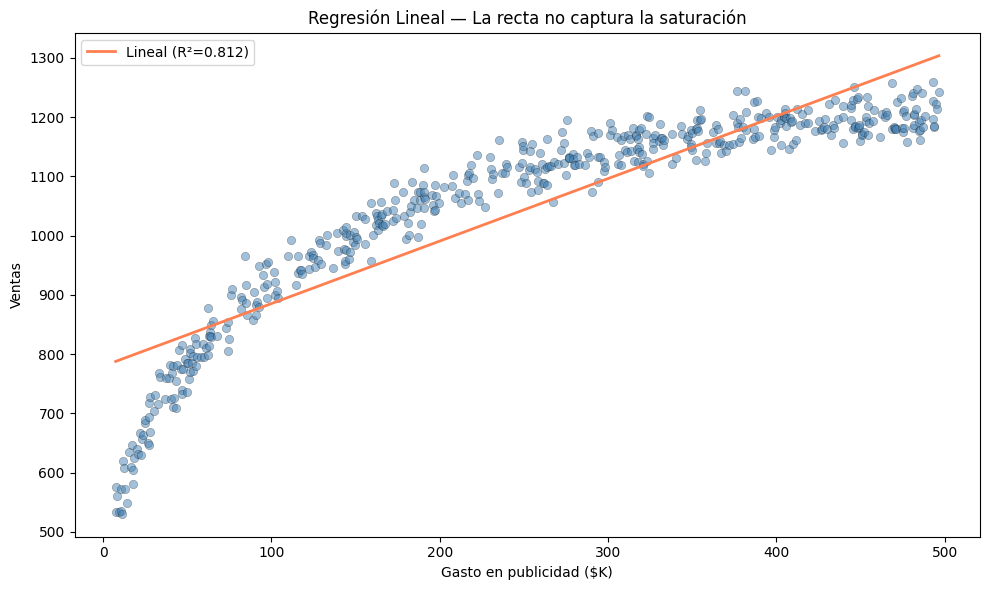

R² = 0.8125
RMSE = 74.9


In [21]:
# Modelo lineal simple
lin = LinearRegression().fit(X, y)
y_lin = lin.predict(X)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    x=df["ad_spend"],
    y=df["sales"],
    ax=ax,
    color="steelblue",
    alpha=0.5,
    edgecolor="k",
    linewidth=0.3,
)
ax.plot(
    X, y_lin, color="coral", linewidth=2, label=f"Lineal (R²={r2_score(y, y_lin):.3f})"
)
ax.set_xlabel("Gasto en publicidad ($K)")
ax.set_ylabel("Ventas")
ax.set_title("Regresión Lineal — La recta no captura la saturación")
ax.legend()
plt.tight_layout()
plt.show()

print(f"R² = {r2_score(y, y_lin):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y, y_lin)):.1f}")

## 2 · Regresión Polinomial

El truco: agregar columnas $X^2$, $X^3$, etc. al dataset. El modelo sigue siendo lineal — pero ahora puede hacer curvas.

$$Y = b_0 + b_1 X + b_2 X^2$$

Cada término tiene su **propio peso**. El modelo decide cuánto "curvar":
- $b_1 X$ → controla la pendiente (inclinación)
- $b_2 X^2$ → controla la curvatura

In [22]:
# PolynomialFeatures crea las columnas X, X², X³... automáticamente
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly2.fit_transform(X)

print("Primeras 5 filas — columnas generadas:")
print(f"{'X':>10} {'X²':>12}")
for row in X_poly2[:5]:
    print(f"{row[0]:>10.1f} {row[1]:>12.1f}")

Primeras 5 filas — columnas generadas:
         X           X²
       7.5         56.2
       7.7         59.3
       8.4         70.6
       9.6         92.2
      10.4        108.2


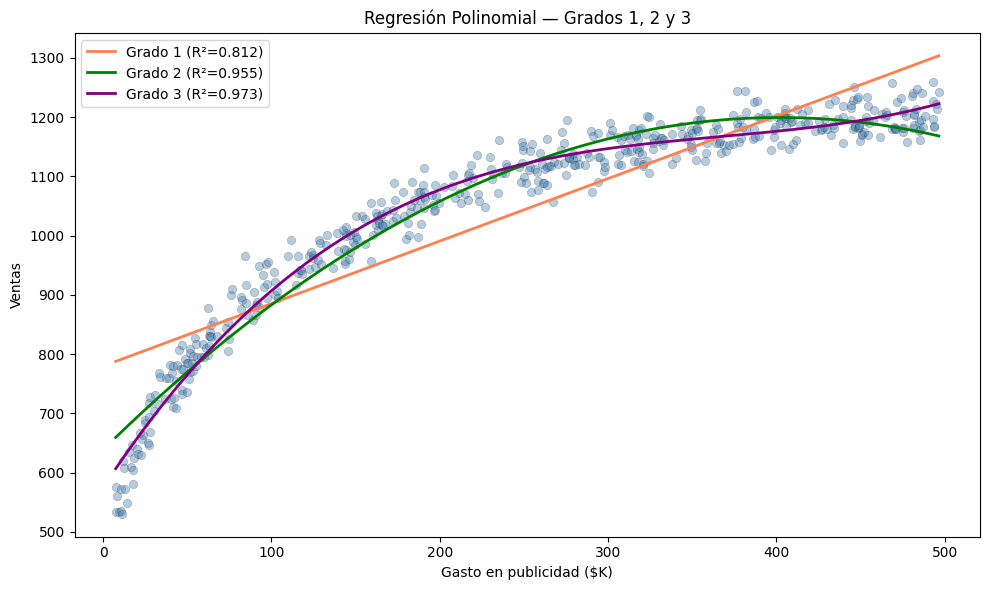

In [23]:
# Comparar grados 1, 2 y 3
x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    x=df["ad_spend"],
    y=df["sales"],
    ax=ax,
    color="steelblue",
    alpha=0.4,
    edgecolor="k",
    linewidth=0.3,
)

colors = ["coral", "green", "purple"]
for degree, color in zip([1, 2, 3], colors):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    model = LinearRegression().fit(poly.fit_transform(X), y)
    y_plot = model.predict(poly.transform(x_plot))
    r2 = r2_score(y, model.predict(poly.transform(X)))
    ax.plot(
        x_plot, y_plot, color=color, linewidth=2, label=f"Grado {degree} (R²={r2:.3f})"
    )

ax.set_xlabel("Gasto en publicidad ($K)")
ax.set_ylabel("Ventas")
ax.set_title("Regresión Polinomial — Grados 1, 2 y 3")
ax.legend()
plt.tight_layout()
plt.show()

## 3 · El Peligro: Overfitting con Grado Alto

¿Qué pasa si subimos el grado demasiado? El modelo "memoriza" los datos y hace olas dementes entre los puntos.

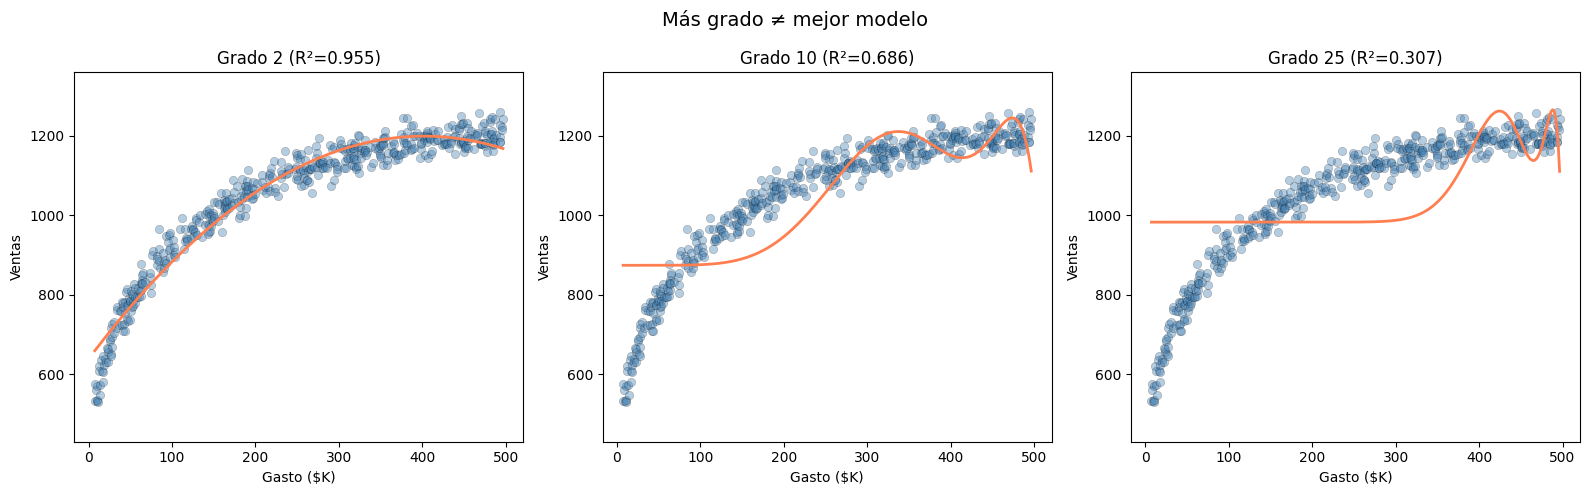

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, degree in zip(axes, [2, 10, 25]):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    model = LinearRegression().fit(poly.fit_transform(X), y)
    y_plot = model.predict(poly.transform(x_plot))
    r2 = r2_score(y, model.predict(poly.transform(X)))

    sns.scatterplot(
        x=df["ad_spend"],
        y=df["sales"],
        ax=ax,
        color="steelblue",
        alpha=0.4,
        edgecolor="k",
        linewidth=0.3,
    )
    ax.plot(x_plot, y_plot, color="coral", linewidth=2)
    ax.set_title(f"Grado {degree} (R²={r2:.3f})")
    ax.set_xlabel("Gasto ($K)")
    ax.set_ylabel("Ventas")
    ax.set_ylim(y.min() - 100, y.max() + 100)

plt.suptitle("Más grado ≠ mejor modelo", fontsize=14)
plt.tight_layout()
plt.show()

## 4 · Splines: Muchas Curvas Simples Conectadas

En vez de UNA curva de grado alto, dividimos el rango en segmentos y usamos un polinomio cúbico (grado 3) en cada uno. Los puntos de conexión se llaman **knots** (nudos).

Cada segmento tiene sus propios coeficientes, pero se conectan **suavemente** (sin saltos ni picos).

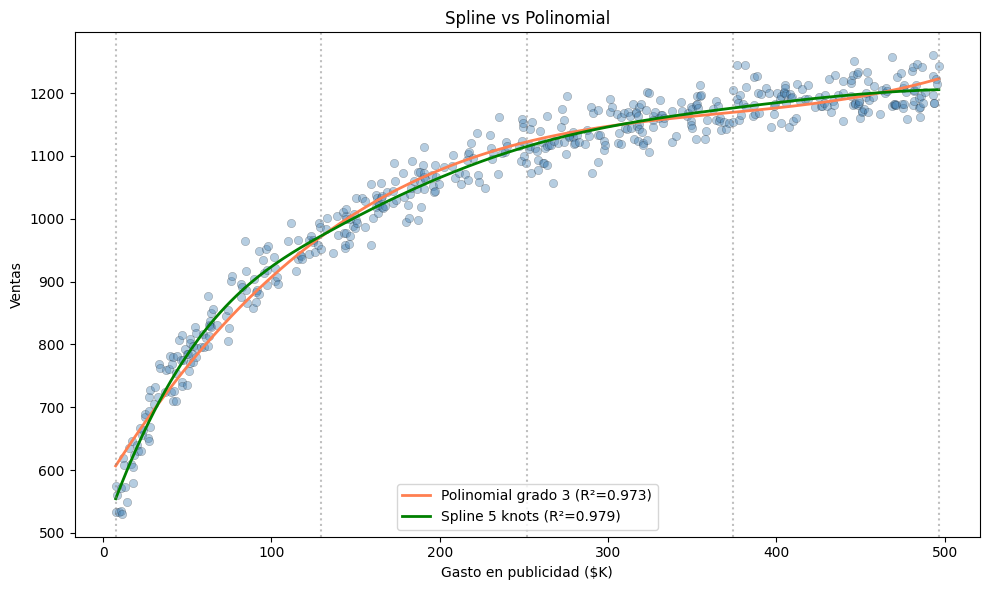

Knots internos: [  7.5 129.8 252.  374.2 496.5]


In [25]:
from sklearn.preprocessing import SplineTransformer

# 5 knots, grado 3 (cúbico) — lo estándar
spline = SplineTransformer(n_knots=5, degree=3)
X_spline = spline.fit_transform(X)

spline_model = LinearRegression().fit(X_spline, y)
y_spline = spline_model.predict(spline.transform(x_plot))

# Comparar con polinomial grado 3
poly3 = PolynomialFeatures(degree=3, include_bias=False)
poly3_model = LinearRegression().fit(poly3.fit_transform(X), y)
y_poly3 = poly3_model.predict(poly3.transform(x_plot))

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    x=df["ad_spend"],
    y=df["sales"],
    ax=ax,
    color="steelblue",
    alpha=0.4,
    edgecolor="k",
    linewidth=0.3,
)
ax.plot(
    x_plot,
    y_poly3,
    color="coral",
    linewidth=2,
    label=f"Polinomial grado 3 (R²={r2_score(y, poly3_model.predict(poly3.transform(X))):.3f})",
)
ax.plot(
    x_plot,
    y_spline,
    color="green",
    linewidth=2,
    label=f"Spline 5 knots (R²={r2_score(y, spline_model.predict(spline.transform(X))):.3f})",
)

# Mostrar los knots
knots = spline.bsplines_[0].t
# Los knots internos (sin los de los bordes repetidos)
internal_knots = knots[3:-3]
for k in internal_knots:
    ax.axvline(k, color="gray", linestyle=":", alpha=0.5)

ax.set_xlabel("Gasto en publicidad ($K)")
ax.set_ylabel("Ventas")
ax.set_title("Spline vs Polinomial")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Knots internos: {internal_knots.round(1)}")

## 5 · ¿Cuántos Knots? El Dilema

Pocos knots → demasiado rígido. Muchos knots → overfitting otra vez.

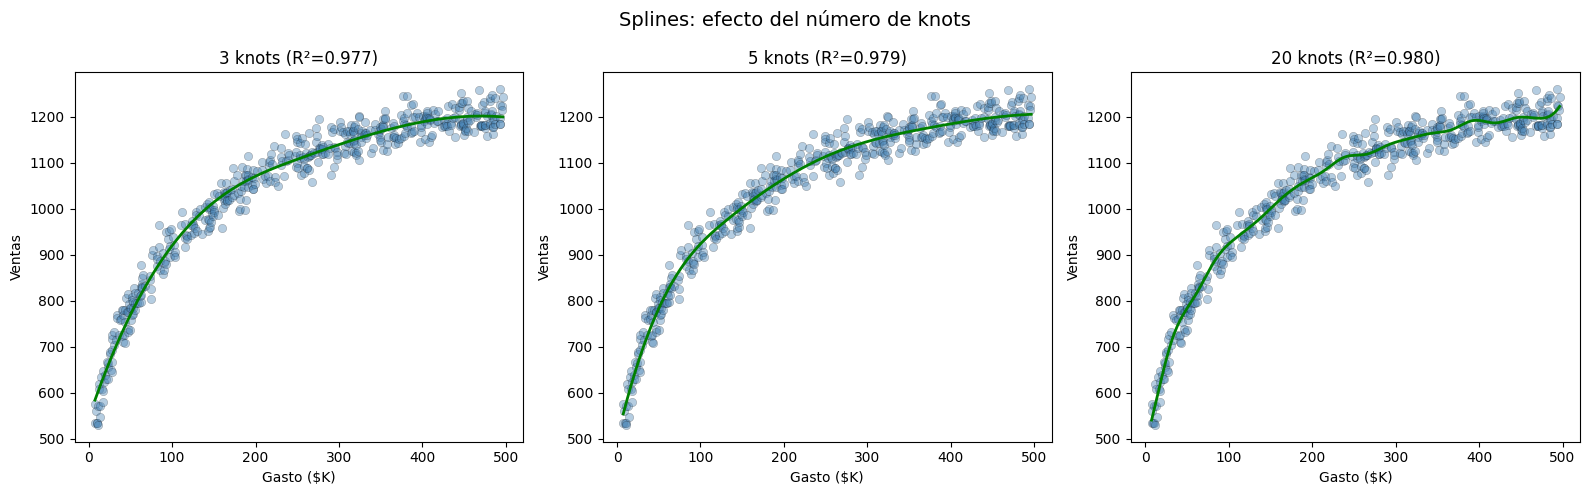

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, n_knots in zip(axes, [3, 5, 20]):
    sp = SplineTransformer(n_knots=n_knots, degree=3)
    sp_model = LinearRegression().fit(sp.fit_transform(X), y)
    y_sp = sp_model.predict(sp.transform(x_plot))
    r2 = r2_score(y, sp_model.predict(sp.transform(X)))

    sns.scatterplot(
        x=df["ad_spend"],
        y=df["sales"],
        ax=ax,
        color="steelblue",
        alpha=0.4,
        edgecolor="k",
        linewidth=0.3,
    )
    ax.plot(x_plot, y_sp, color="green", linewidth=2)
    ax.set_title(f"{n_knots} knots (R²={r2:.3f})")
    ax.set_xlabel("Gasto ($K)")
    ax.set_ylabel("Ventas")

plt.suptitle("Splines: efecto del número de knots", fontsize=14)
plt.tight_layout()
plt.show()

## 6 · GAMs: Splines Automáticos

Un **GAM** (Generalized Additive Model) elige automáticamente cuántos knots usar. Es como pasar de carro manual a automático.

`pyGAM` es la librería dedicada, pero no es compatible con NumPy 2.x. Podemos simular la idea con **sklearn**: probar varios `n_knots` y elegir el mejor con cross-validation.

Mejor n_knots: 3 (CV RMSE = 86.6)


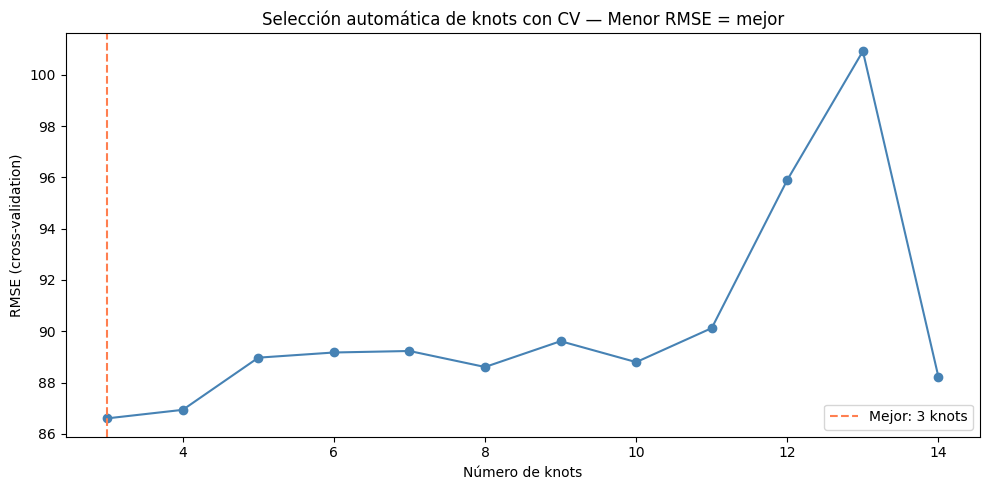

In [27]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# Probar diferentes números de knots y elegir el mejor con CV
results = []
knot_range = range(3, 15)

for n_k in knot_range:
    pipe = make_pipeline(SplineTransformer(n_knots=n_k, degree=3), LinearRegression())
    # neg_mean_squared_error es más estable que r2 con pocos datos
    cv_score = -cross_val_score(
        pipe, X, y, cv=5, scoring="neg_mean_squared_error"
    ).mean()
    results.append({"n_knots": n_k, "cv_mse": cv_score})

results_df = pd.DataFrame(results)
best = results_df.loc[results_df["cv_mse"].idxmin()]

print(
    f"Mejor n_knots: {int(best['n_knots'])} (CV RMSE = {np.sqrt(best['cv_mse']):.1f})"
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df["n_knots"], np.sqrt(results_df["cv_mse"]), "o-", color="steelblue")
ax.axvline(
    best["n_knots"],
    color="coral",
    linestyle="--",
    label=f"Mejor: {int(best['n_knots'])} knots",
)
ax.set_xlabel("Número de knots")
ax.set_ylabel("RMSE (cross-validation)")
ax.set_title("Selección automática de knots con CV — Menor RMSE = mejor")
ax.legend()
plt.tight_layout()
plt.show()

## 7 · Splines con Múltiples Predictores

Usamos el dataset de apartamentos (notebook 16). `SplineTransformer` aplica splines a **todas** las columnas — cada predictor obtiene su propia curva.

In [28]:
df_apt = pd.read_csv("../data/apartments.csv")
X_apt = df_apt[["area", "rooms", "distance_km", "age"]].values
y_apt = df_apt["price"].to_numpy()
pred_names = ["area", "rooms", "distance_km", "age"]

# Modelo lineal vs spline
lin_apt = LinearRegression().fit(X_apt, y_apt)
spline_apt = make_pipeline(
    SplineTransformer(n_knots=5, degree=3), LinearRegression()
).fit(X_apt, y_apt)

print(f"{'Modelo':<20} {'R²':>8}")
print(f"{'Lineal':<20} {r2_score(y_apt, lin_apt.predict(X_apt)):>8.4f}")
print(f"{'Spline (5 knots)':<20} {r2_score(y_apt, spline_apt.predict(X_apt)):>8.4f}")

Modelo                     R²
Lineal                 0.8972
Spline (5 knots)       0.9358


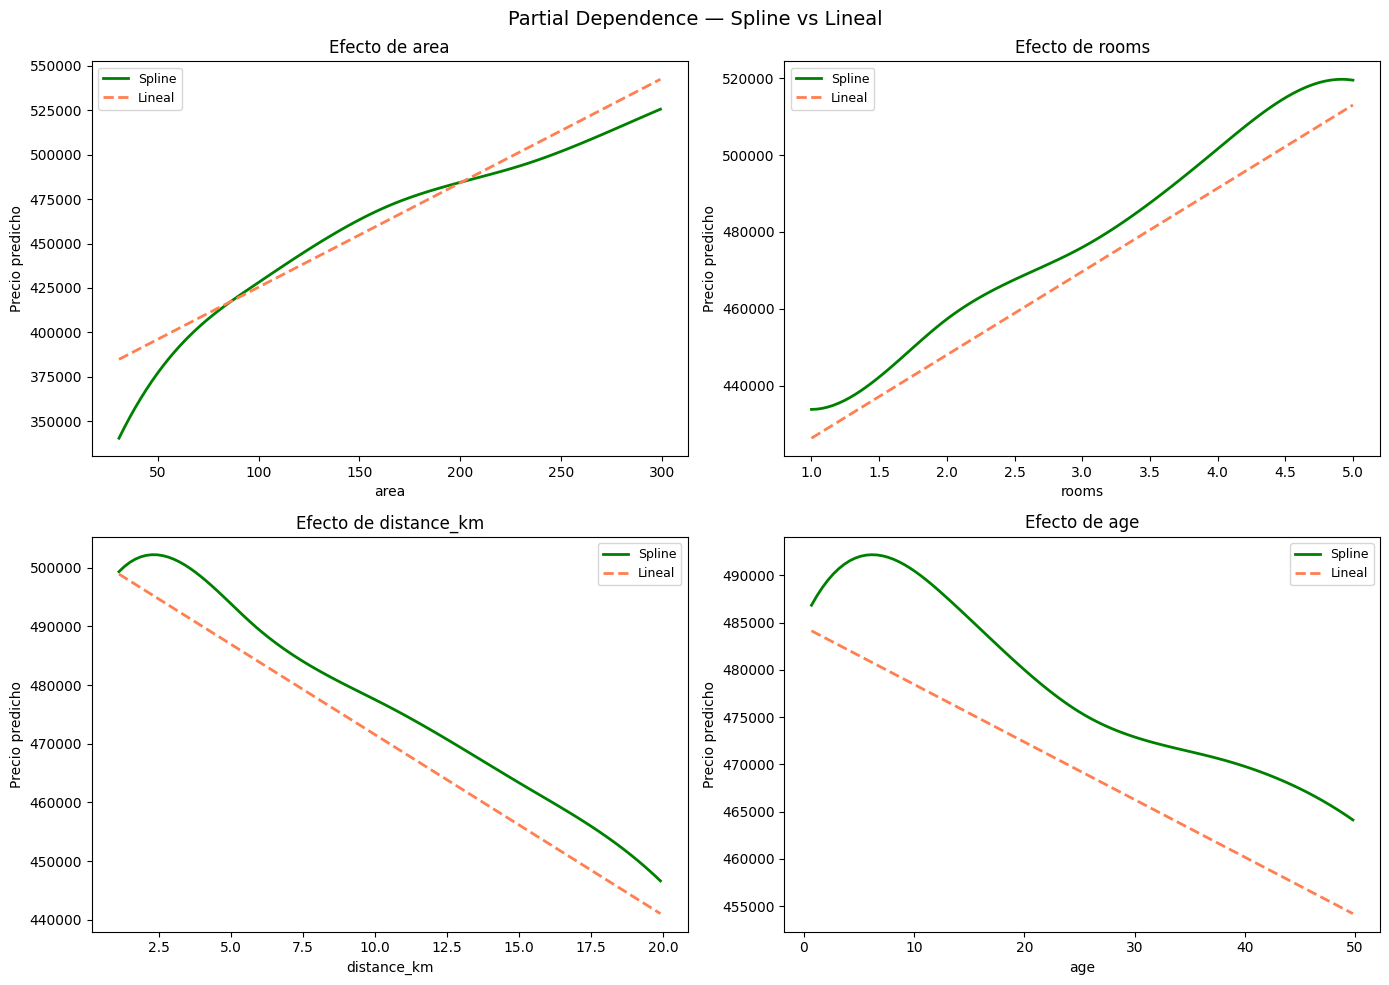

In [29]:
# Partial dependence: cómo cambia la predicción al variar cada predictor
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (ax, name) in enumerate(zip(axes.flat, pred_names)):
    # Crear grid variando solo el predictor i, dejando los demás en su mediana
    x_grid = np.tile(np.median(X_apt, axis=0), (100, 1))
    x_range = np.linspace(X_apt[:, i].min(), X_apt[:, i].max(), 100)
    x_grid[:, i] = x_range

    y_spline_pd = spline_apt.predict(x_grid)
    y_lin_pd = lin_apt.predict(x_grid)

    ax.plot(x_range, y_spline_pd, color="green", linewidth=2, label="Spline")
    ax.plot(
        x_range, y_lin_pd, color="coral", linewidth=2, linestyle="--", label="Lineal"
    )
    ax.set_xlabel(name)
    ax.set_ylabel("Precio predicho")
    ax.set_title(f"Efecto de {name}")
    ax.legend(fontsize=9)

plt.suptitle("Partial Dependence — Spline vs Lineal", fontsize=14)
plt.tight_layout()
plt.show()

## 8 · La Prueba Real: train_test_split

Hasta ahora medimos R² sobre los **mismos datos** con los que entrenamos — eso favorece a los modelos más complejos (overfitting). La prueba real es predecir datos que el modelo **nunca vio**.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} filas, Test: {len(X_test)} filas")

# Entrenar cada modelo solo con train, evaluar con test
pipelines = {
    "Lineal": make_pipeline(LinearRegression()),
    "Polinomial (grado 2)": make_pipeline(
        PolynomialFeatures(2, include_bias=False), LinearRegression()
    ),
    "Polinomial (grado 3)": make_pipeline(
        PolynomialFeatures(3, include_bias=False), LinearRegression()
    ),
    "Polinomial (grado 10)": make_pipeline(
        PolynomialFeatures(10, include_bias=False), LinearRegression()
    ),
    "Polinomial (grado 25)": make_pipeline(
        PolynomialFeatures(25, include_bias=False), LinearRegression()
    ),
    "Spline (5 knots)": make_pipeline(
        SplineTransformer(n_knots=5, degree=3), LinearRegression()
    ),
    "Spline (20 knots)": make_pipeline(
        SplineTransformer(n_knots=20, degree=3), LinearRegression()
    ),
}

print(f"\n{'Modelo':<25} {'R² train':>10} {'R² test':>10} {'RMSE test':>10}")
print("-" * 57)
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    r2_tr = r2_score(y_train, pipe.predict(X_train))
    r2_te = r2_score(y_test, pipe.predict(X_test))
    rmse_te = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
    flag = " 🚨" if r2_tr - r2_te > 0.05 else ""
    print(f"{name:<25} {r2_tr:>10.4f} {r2_te:>10.4f} {rmse_te:>10.1f}{flag}")

Train: 400 filas, Test: 100 filas

Modelo                      R² train    R² test  RMSE test
---------------------------------------------------------
Lineal                        0.8020     0.8403       77.5
Polinomial (grado 2)          0.9536     0.9605       38.5
Polinomial (grado 3)          0.9719     0.9779       28.8
Polinomial (grado 10)         0.6711     0.7245      101.8
Polinomial (grado 25)         0.2885     0.3518      156.1
Spline (5 knots)              0.9774     0.9827       25.5
Spline (20 knots)             0.9783     0.9834       24.9


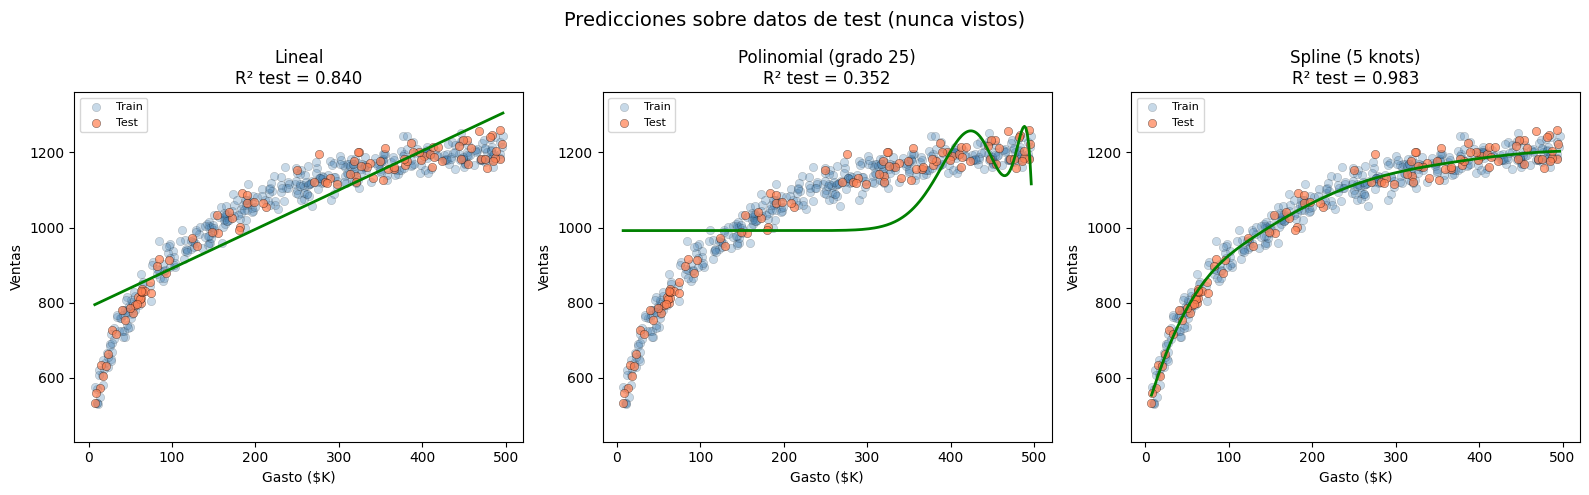

In [31]:
# Visualizar las predicciones en test — los 3 modelos más interesantes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

selected = {
    "Lineal": pipelines["Lineal"],
    "Polinomial (grado 25)": pipelines["Polinomial (grado 25)"],
    "Spline (5 knots)": pipelines["Spline (5 knots)"],
}

for ax, (name, pipe) in zip(axes, selected.items()):
    r2_te = r2_score(y_test, pipe.predict(X_test))

    sns.scatterplot(
        x=X_train.ravel(),
        y=y_train,
        ax=ax,
        color="steelblue",
        alpha=0.3,
        edgecolor="k",
        linewidth=0.3,
        label="Train",
    )
    sns.scatterplot(
        x=X_test.ravel(),
        y=y_test,
        ax=ax,
        color="coral",
        alpha=0.7,
        edgecolor="k",
        linewidth=0.3,
        label="Test",
    )
    ax.plot(x_plot, pipe.predict(x_plot), color="green", linewidth=2)
    ax.set_title(f"{name}\nR² test = {r2_te:.3f}")
    ax.set_xlabel("Gasto ($K)")
    ax.set_ylabel("Ventas")
    ax.legend(fontsize=8)
    ax.set_ylim(y.min() - 100, y.max() + 100)

plt.suptitle("Predicciones sobre datos de test (nunca vistos)", fontsize=14)
plt.tight_layout()
plt.show()

## 9 · Resumen

| Concepto | Descripción |
|----------|-------------|
| Polinomial | Agrega $X^2, X^3...$ como columnas. UNA curva para todo el rango |
| Spline | Divide el rango en segmentos con **knots**. Cada segmento: polinomio cúbico |
| Knots | Puntos donde se conectan los segmentos del spline |
| GAM | Spline con selección automática de knots (con CV o librerías como `pyGAM`) |
| train_test_split | La prueba real: R² sobre datos que el modelo nunca vio |
| Overfitting | R² train alto pero R² test bajo → el modelo memorizó |

| Cuándo usar qué |  |
|------------------|--|
| Curvatura simple (log, cuadrática) | Polinomial grado 2-3 o transformación |
| Curvatura compleja | Spline con cross-validation |
| Múltiples predictores no lineales | Spline por cada predictor (GAM) |

> 👈 Un modelo que funciona bien en train pero mal en test es inútil. Siempre evalúa con datos que el modelo no vio.